## 1. Imports y Configuracion


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configuramos la paleta de Seaborn predeterminada a "Set1" (que tiene rojo y azul)
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga de Datos


In [5]:
from google.colab import drive
drive.mount('/content/drive')

trans = pd.read_csv('/content/drive/MyDrive/Datasets/Final Project/HI-Small_Trans.csv')
accounts = pd.read_csv('/content/drive/MyDrive/Datasets/Final Project/HI-Small_accounts.csv')

Mounted at /content/drive


## 3. Funcion de Limpieza


In [6]:
def clean_data(trans_df: pd.DataFrame,
               accounts_df: pd.DataFrame) -> pd.DataFrame:

    df  = trans_df.copy()
    acc = accounts_df.drop_duplicates(subset='Account Number', keep='first').copy()

    # --- Duplicados exactos ---
    n_before = len(df)
    df = df.drop_duplicates()
    n_dropped = n_before - len(df)

    # --- Timestamp a datetime y orden cronologico ---
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)

    # --- Merge con tabla de cuentas (origen y destino) ---
    df = df.merge(
        acc[['Account Number', 'Entity Name']].rename(
            columns={'Account Number': 'Account',
                     'Entity Name'  : 'From Entity Name'}),
        on='Account', how='left'
    )
    df = df.merge(
        acc[['Account Number', 'Entity Name']].rename(
            columns={'Account Number': 'Account.1',
                     'Entity Name'  : 'To Entity Name'}),
        on='Account.1', how='left'
    )

    # --- Extraccion del tipo de entidad ---
    df['From Entity Type'] = (
        df['From Entity Name'].str.extract(r'^([\w\s]+?)\s*#').fillna('Unknown')
    )
    df['To Entity Type'] = (
        df['To Entity Name'].str.extract(r'^([\w\s]+?)\s*#').fillna('Unknown')
    )

    return df

In [10]:
df = clean_data(trans, accounts)
df.head(3)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From Entity Name,To Entity Name,From Entity Type,To Entity Type
0,2022-09-01,32282,801B64CE0,32282,801B64CE0,29294.0300,US Dollar,29294.0300,US Dollar,Reinvestment,0,Sole Proprietorship #4172,Sole Proprietorship #4172,Sole Proprietorship,Sole Proprietorship
1,2022-09-01,212818,804B1DF50,212818,804B1DF50,538528.5300,Rupee,538528.5300,Rupee,Reinvestment,0,Partnership #32618,Partnership #32618,Partnership,Partnership
2,2022-09-01,16927,8062913A0,28,806291440,96718657.0000,Ruble,96718657.0000,Ruble,ACH,0,Partnership #34005,Partnership #33832,Partnership,Partnership


## 4. Pipeline de Ingenieria de Caracteristicas


In [11]:
def _expanding_agg(df: pd.DataFrame,
                   group_col: str,
                   value_col: str,
                   agg_funcs: dict,
                   prefix: str) -> pd.DataFrame:

    grp = df.groupby(group_col)[value_col]
    for suffix, func in agg_funcs.items():
        df[f'{prefix}_{suffix}'] = (
            grp.expanding().agg(func)
               .shift(1)
               .reset_index(level=0, drop=True)
        )
    return df


def _expanding_nunique_shift(df: pd.DataFrame,
                              group_col: str,
                              target_col: str,
                              new_col: str) -> pd.DataFrame:
    """
    Cuenta contrapartes unicas acumuladas por cuenta usando shift(1).
    Implementacion con diccionario de conjuntos para eficiencia O(n).
    """
    seen   = {}
    result = []
    for g, t in zip(df[group_col], df[target_col]):
        seen.setdefault(g, set())
        result.append(len(seen[g]))   # antes de agregar la actual
        seen[g].add(t)
    df[new_col] = result
    return df

In [12]:
def build_features(df: pd.DataFrame) -> dict:

    out = df.copy()

    # FEATURES TEMPORALES

    out['Hour']    = out['Timestamp'].dt.hour
    out['DayNum']  = out['Timestamp'].dt.dayofweek   # 0=Lun, 6=Dom

    out['Hour_sin']  = np.sin(2 * np.pi * out['Hour']   / 24)
    out['Hour_cos']  = np.cos(2 * np.pi * out['Hour']   / 24)
    out['Day_sin']   = np.sin(2 * np.pi * out['DayNum'] / 7)
    out['Day_cos']   = np.cos(2 * np.pi * out['DayNum'] / 7)

    # Binarios interpretables
    out['Is_Night']   = out['Hour'].apply(lambda h: int(h >= 22 or h < 6))
    out['Is_Weekend'] = (out['DayNum'] >= 5).astype(int)

    # FEATURES DE MONTO
    out['Log Amount Paid']     = np.log1p(out['Amount Paid'])
    out['Log Amount Received'] = np.log1p(out['Amount Received'])

    # Diferencia en escala log -> robusta ante outliers
    out['Log Amount Diff']  = np.log1p(np.abs(out['Amount Paid'] - out['Amount Received']))

    # Ratio en escala log: log(Paid) - log(Received) = log(Paid/Received)
    # Evita los valores extremos del ratio lineal cuando Received ~ 0
    out['Log Amount Ratio'] = (
        np.log1p(out['Amount Paid']) - np.log1p(out['Amount Received'] + 1e-8)
    )

    out['Currency Mismatch'] = (out['Payment Currency'] != out['Receiving Currency']).astype(int)
    out['Self Transaction']  = (out['Account'] == out['Account.1']).astype(int)
    out['Same Bank']         = (out['From Bank'] == out['To Bank']).astype(int)

    # AGREGACIONES HISTORICAS POR CUENTA  (expanding + shift)

    agg_funcs = {'mean': 'mean', 'std': 'std', 'count': 'count'}

    out = _expanding_agg(out, 'Account',   'Amount Paid',      agg_funcs, 'From_Hist')
    out = _expanding_agg(out, 'Account.1', 'Amount Received',  agg_funcs, 'To_Hist')

    # Cold-start: primera transaccion de cada cuenta -> rellenar con media global
    gm_paid = out['Amount Paid'].mean();     gs_paid = out['Amount Paid'].std()
    gm_recv = out['Amount Received'].mean(); gs_recv = out['Amount Received'].std()

    out['From_Hist_mean']  = out['From_Hist_mean'].fillna(gm_paid)
    out['From_Hist_std']   = out['From_Hist_std'].fillna(gs_paid)
    out['From_Hist_count'] = out['From_Hist_count'].fillna(0)
    out['To_Hist_mean']    = out['To_Hist_mean'].fillna(gm_recv)
    out['To_Hist_std']     = out['To_Hist_std'].fillna(gs_recv)
    out['To_Hist_count']   = out['To_Hist_count'].fillna(0)

    # Z-score del monto vs historico de esa cuenta (clippeado a [-10, 10])
    out['Amount_Zscore_From'] = (
        (out['Amount Paid'] - out['From_Hist_mean']) / (out['From_Hist_std'] + 1e-8)
    ).clip(-10, 10)

    out['Amount_Zscore_To'] = (
        (out['Amount Received'] - out['To_Hist_mean']) / (out['To_Hist_std'] + 1e-8)
    ).clip(-10, 10)

    out['Log_From_Hist_count'] = np.log1p(out['From_Hist_count'])
    out['Log_To_Hist_count']   = np.log1p(out['To_Hist_count'])


    # FEATURES DE GRAFO
    out = _expanding_nunique_shift(out, 'Account',   'Account.1', 'From_Unique_Dest')
    out = _expanding_nunique_shift(out, 'Account.1', 'Account',   'To_Unique_Src')

    out['Log_From_Unique_Dest'] = np.log1p(out['From_Unique_Dest'])
    out['Log_To_Unique_Src']    = np.log1p(out['To_Unique_Src'])

    # Frecuencia historica del par exacto (Account -> Account.1)
    pair_count, pair_freq = {}, []
    for pair in (out['Account'].astype(str) + '_' + out['Account.1'].astype(str)):
        pair_freq.append(pair_count.get(pair, 0))
        pair_count[pair] = pair_count.get(pair, 0) + 1
    out['Log_Pair_Freq'] = np.log1p(pair_freq)

    # ENCODING DE ENTIDADES
    out['Entity Combo'] = out['From Entity Type'] + '_TO_' + out['To Entity Type']

    le_from  = LabelEncoder().fit(out['From Entity Type'].astype(str))
    le_to    = LabelEncoder().fit(out['To Entity Type'].astype(str))
    le_combo = LabelEncoder().fit(out['Entity Combo'].astype(str))

    out['From_Entity_LE']  = le_from.transform(out['From Entity Type'].astype(str))
    out['To_Entity_LE']    = le_to.transform(out['To Entity Type'].astype(str))
    out['Entity_Combo_LE'] = le_combo.transform(out['Entity Combo'].astype(str))

    # ONE-HOT ENCODING
    cat_cols = ['Payment Format', 'Payment Currency']
    out = pd.get_dummies(out, columns=cat_cols,
                         prefix=['PayFmt', 'PayCur'],
                         sparse=True, dtype='uint8')
    ohe_cols = [c for c in out.columns if c.startswith(('PayFmt_', 'PayCur_'))]

    # SELECCION FINAL

    FEATURES_BASE = [
        'Log Amount Paid', 'Log Amount Received',
        'Log Amount Diff', 'Log Amount Ratio',
        'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos',
        'Is_Night', 'Is_Weekend',
        'Currency Mismatch', 'Self Transaction', 'Same Bank',
        'Amount_Zscore_From', 'Log_From_Hist_count',
        'Amount_Zscore_To',   'Log_To_Hist_count',
        'Log_From_Unique_Dest', 'Log_To_Unique_Src',
        'Log_Pair_Freq',
        'From_Entity_LE', 'To_Entity_LE', 'Entity_Combo_LE',
    ]
    FEATURES_TE  = ['From Entity Type', 'To Entity Type', 'Entity Combo']
    FEATURES_ALL = FEATURES_BASE + ohe_cols

    X = out[FEATURES_ALL]
    y = out['Is Laundering']

    return {
        'X'             : X,
        'y'             : y,
        'feature_names' : FEATURES_ALL,
        'features_base' : FEATURES_BASE,
        'features_ohe'  : ohe_cols,
        'features_te'   : FEATURES_TE,
        'label_encoders': {'from': le_from, 'to': le_to, 'combo': le_combo},
        'df_full'       : out,
    }

In [13]:
pipeline_output = build_features(df)

X = pipeline_output['X']
y = pipeline_output['y']

## 5. Division Train / Test Cronologica


In [14]:
n       = len(df)
n_train = int(n * 0.8)

X_train, y_train = X.iloc[:n_train],  y.iloc[:n_train]
X_test,  y_test  = X.iloc[n_train:],  y.iloc[n_train:]

print(f"{'Conjunto':<12} {'Filas':>10} {'Lavado':>10} {'% Lavado':>10}")
print("-" * 44)
for name, ys in [('Train', y_train), ('Test', y_test)]:
    print(f"{name:<12} {len(ys):>10,} {ys.sum():>10,} {ys.mean()*100:>9.4f}%")

ts = pipeline_output['df_full']['Timestamp']
print(f"\nCortes temporales:")
print(f"  Train : {ts.iloc[0].date()} -> {ts.iloc[n_train-1].date()}")
print(f"  Test  : {ts.iloc[n_train].date()} -> {ts.iloc[-1].date()}")

Conjunto          Filas     Lavado   % Lavado
--------------------------------------------
Train         4,062,668      3,379    0.0832%
Test          1,015,668      1,798    0.1770%

Cortes temporales:
  Train : 2022-09-01 -> 2022-09-08
  Test  : 2022-09-08 -> 2022-09-18


# **Data Export**


In [16]:
import os

base_path = '/content/drive/MyDrive/Datasets/Final Project/Processed/'
os.makedirs(base_path, exist_ok=True)

# Helper function to convert sparse columns to dense, as Parquet doesn't support sparse data
def convert_sparse_to_dense(df):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_sparse(df[col]):
            df[col] = df[col].sparse.to_dense()
    return df

X_train_dense = convert_sparse_to_dense(X_train)
X_test_dense = convert_sparse_to_dense(X_test)

X_train_dense.to_parquet(f'{base_path}X_train.parquet', index=False)
X_test_dense.to_parquet(f'{base_path}X_test.parquet', index=False)

pd.DataFrame(y_train).to_parquet(f'{base_path}y_train.parquet', index=False)
pd.DataFrame(y_test).to_parquet(f'{base_path}y_test.parquet', index=False)

## 7. Visualizacion de Nuevas Features


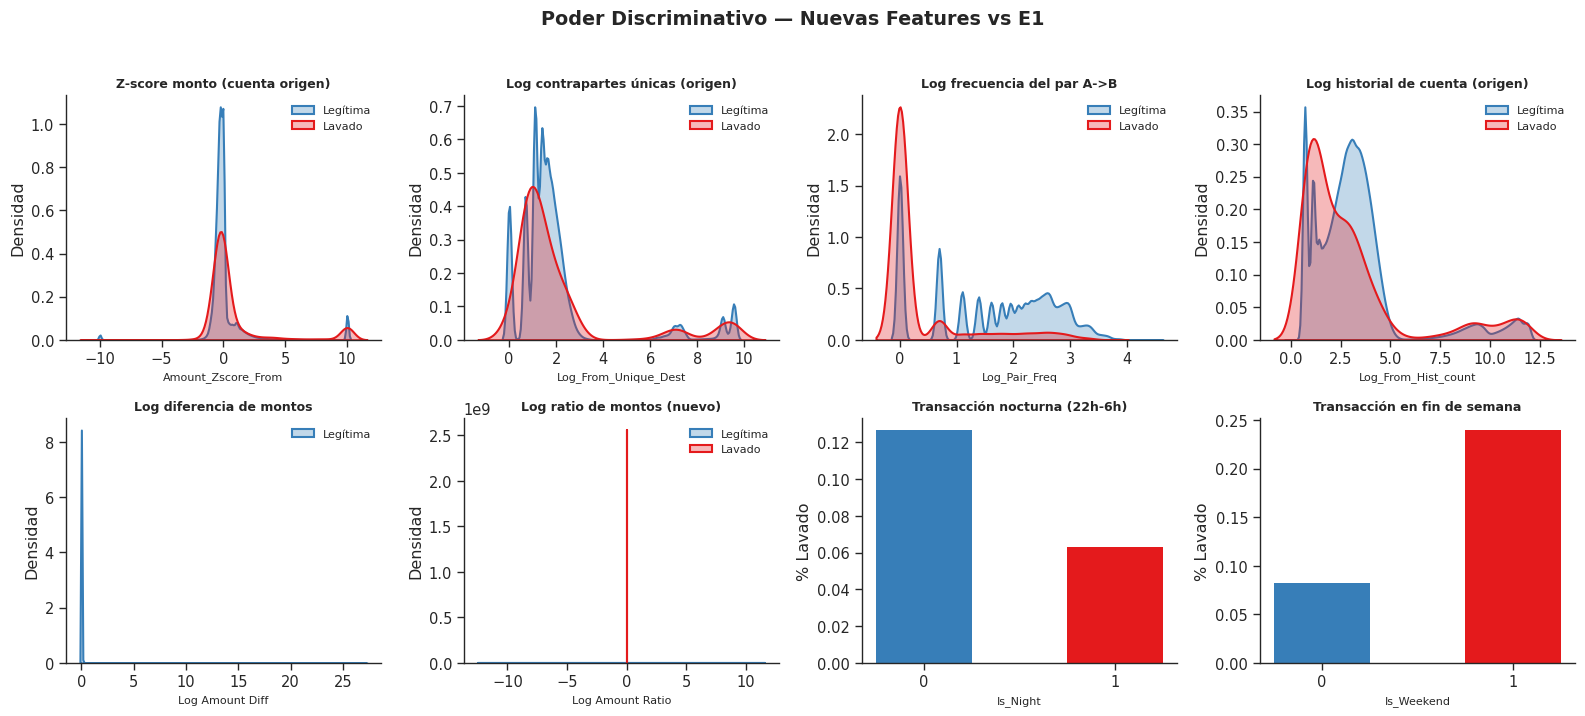

In [ ]:
df_full = pipeline_output['df_full']

features_to_plot = [
    ('Amount_Zscore_From',    'Z-score monto (cuenta origen)'),
    ('Log_From_Unique_Dest',  'Log contrapartes únicas (origen)'),
    ('Log_Pair_Freq',         'Log frecuencia del par A->B'),
    ('Log_From_Hist_count',   'Log historial de cuenta (origen)'),
    ('Log Amount Diff',       'Log diferencia de montos'),
    ('Log Amount Ratio',      'Log ratio de montos (nuevo)'),
    ('Is_Night',              'Transacción nocturna (22h-6h)'),
    ('Is_Weekend',            'Transacción en fin de semana'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

# Tomamos colores de la paleta por defecto de seaborn ('Set1')
colors = sns.color_palette()
c_legit = colors[1] # Azul (índice 1 en Set1)
c_fraud = colors[0] # Rojo (índice 0 en Set1)

for ax, (feat, title) in zip(axes, features_to_plot):
    legit_vals = df_full.loc[df_full['Is Laundering'] == 0, feat]
    fraud_vals = df_full.loc[df_full['Is Laundering'] == 1, feat]

    if df_full[feat].nunique() <= 2:
        rates = df_full.groupby(feat)['Is Laundering'].mean() * 100
        ax.bar(rates.index.astype(str), rates.values,
               color=[c_legit, c_fraud],
               edgecolor='none', width=0.5)
        ax.set_ylabel('% Lavado')
    else:
        sns.kdeplot(legit_vals, ax=ax, color=c_legit,
                    fill=True, alpha=0.3, linewidth=1.5, label='Legítima')
        sns.kdeplot(fraud_vals, ax=ax, color=c_fraud,
                    fill=True, alpha=0.3, linewidth=1.5, label='Lavado')
        ax.legend(frameon=False, fontsize=8)
        ax.set_ylabel('Densidad')

    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Poder Discriminativo — Nuevas Features vs E1', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()